In [2]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
#from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm
import xesmf as xe
import glob

In [18]:
files = sorted(glob.glob("/climca/data/ERA5/mon/u/*.nc"))

u850_list = []

for file in files:
    ds = xr.open_dataset(file)
    u850 = (
        ds.sel(plev=85000)
          .drop_vars("plev")
    )
    u850_list.append(u850)

u850 = xr.concat(u850_list, dim="time")

KeyboardInterrupt: 

In [ ]:
u850

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 1015, lat: 640, lon: 1280)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-01T12:00:00 ... 2024-06-01T12:...
  * lon      (lon) float64 10kB 0.0 0.2812 0.5625 0.8438 ... 359.2 359.4 359.7
  * lat      (lat) float64 5kB 89.78 89.51 89.23 88.95 ... -89.23 -89.51 -89.78
Data variables:
    U        (time, lat, lon) float32 3GB -5.979 -5.974 -5.969 ... -1.427 -1.402
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Sep 11 11:11:03 2024: cdo -O -s -r -t ecmwf -b 32 -f nc...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [ ]:
ug = u850.sortby(['lat', 'lon'])
#display(ug_x.lon[0])

# Target grid 1.0x1.0 resolution
ds_out = xe.util.grid_global(1.0, 1.0)

# Regrid
regridder = xe.Regridder(
    ug, ds_out,
    'bilinear',
    periodic=True,
    ignore_degenerate=True
)

ds_1deg = regridder(ug, keep_attrs=True)

# Extract 1D coords
lon_1d = ds_1deg.lon[0, :].values
lat_1d = ds_1deg.lat[:, 0].values

# Assign AND enforce them as dimension coords
ds_1deg = ds_1deg.rename({"x": "lon", "y": "lat"})

ds_1deg = ds_1deg.assign_coords({
    "lon": ("lon", lon_1d),
    "lat": ("lat", lat_1d)
})

display(ds_1deg)
ug_x = ds_1deg.sel(time=slice('1950','2025'),lat=slice(-90,0))



<xarray.Dataset> Size: 263MB
Dimensions:  (time: 1015, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-01T12:00:00 ... 2024-06-01T12:...
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    U        (time, lat, lon) float32 263MB 1.616 1.584 1.551 ... 3.118 3.159
Attributes:
    CDI:            Climate Data Interface version 2.2.4 (https://mpimet.mpg....
    Conventions:    CF-1.6
    institution:    European Centre for Medium-Range Weather Forecasts
    history:        Wed Sep 11 11:11:03 2024: cdo -O -s -r -t ecmwf -b 32 -f ...
    CDO:            Climate Data Operators version 2.2.2 (https://mpimet.mpg....
    regrid_method:  bilinear

In [ ]:
type(ug_x)

xarray.core.dataset.Dataset

In [ ]:
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def var_prepper(da, months_list, wghts_bool=True, name='Z500'):
    da_sel=extract_seasonal_data(da, months_list)
    ##1 Anomalies
    da_an=compute_anomaly(da_sel)
    print('Anomalies computed')
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    print('Data is detrended')
    ##cut the weight by latitude part
    da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season= da_wght #extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    #da_masked=sea_mask(da_season_mean) #not necessary for 500hPa?
    if type(da_season_mean)!=xr.core.dataset.Dataset:
        da_masked=da_season_mean.to_dataset(name=name)
    else:
        da_masked=da_season_mean

    return da_masked

In [ ]:
ug_SON=var_prepper(ug_x, [9,10,11], name='U850')
ug_DJF=var_prepper(ug_x, [12,1,2], name='U850')

Anomalies computed
Data is detrended
Anomalies computed
Data is detrended


In [ ]:
years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

u850_SON=exclude_years_xr(ug_SON, years_to_drop)

cut_years=[1950,2003,2020,2025]
u850_DJF=exclude_years_xr(ug_DJF, cut_years)

In [ ]:
display(u850_DJF)

path='ERA5_dyn_data_ready/'
u850_SON.to_netcdf(path=path+'u850_SON.nc', format='NETCDF4')
u850_DJF.to_netcdf(path=path+'u850_DJF.nc', format='NETCDF4')

<xarray.Dataset> Size: 19MB
Dimensions:  (lon: 360, lat: 90, year: 72)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5
  * year     (year) int64 576B 1951 1952 1953 1954 1955 ... 2021 2022 2023 2024
Data variables:
    U        (year, lat, lon) float64 19MB -0.08565 -0.08698 ... 1.15 1.168

JUST START HERE

In [3]:
u850_SON=xr.open_dataset('ERA5_dyn_data_ready/u850_SON.nc')
u850_DJF=xr.open_dataset('ERA5_dyn_data_ready/u850_DJF.nc')

In [4]:
display(u850_SON)

<xarray.Dataset> Size: 18MB
Dimensions:  (lon: 360, lat: 90, year: 71)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5
  * year     (year) int64 568B 1951 1952 1953 1954 1955 ... 2020 2021 2022 2023
Data variables:
    U        (year, lat, lon) float64 18MB ...

In [5]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

In [6]:
##SON data
ds_SON = xr.merge([u850_SON, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([u850_DJF, era_DJF_LaPlata_array])

Regressions and Maps

In [7]:


def lin_model_fast(y, x_main, *x_controls):
    """
    y         : (window,)
    x_main    : (window,)
    x_controls: (window,)

    Returns
    -------
    coef_main : float
    """

    # stack predictors
    X_list = [x_main] + list(x_controls)
    X = np.stack(X_list, axis=1)  # shape (window, n_predictors)

    # remove NaNs
    mask = ~np.any(np.isnan(X), axis=1) & ~np.isnan(y)
    if mask.sum() < X.shape[1]:  # not enough data
        return np.nan

    X = X[mask]
    y = y[mask]

    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        return beta[0]  # coefficient of main predictor
    except np.linalg.LinAlgError:
        return np.nan
import xarray as xr

def sensitivity_analysis_fast(ds_rolled, target, driver, controls=None):
    """
    Perform regression for each grid point and rolling window.

    Parameters
    ----------
    ds_rolled : Dataset (year, window, lat, lon)
    target    : str (e.g. 't2m')
    driver    : str (main predictor, e.g. 'ENSO')
    controls  : list of str (optional)

    Returns
    -------
    coef_da : DataArray (year, lat, lon)
    """

    y = ds_rolled[target]
    x_main = ds_rolled[driver]

    if controls is not None:
        x_controls = [ds_rolled[var] for var in controls]
    else:
        x_controls = []

    coef = xr.apply_ufunc(
        lin_model_fast,
        y,
        x_main,
        *x_controls,
        input_core_dims=[["window"]] * (2 + len(x_controls)),
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return coef


def conditioning_everything_fast(ds, driver_list, target, total_eff=False):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif 'SPV' in driver_list and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'S_SAM']]

        else:
            if driver == 'IOD':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            else:
                controls = None

        coef = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
        )

        mean_coef = coef.mean(dim="year")

        results.append(mean_coef)

        print(f"{driver} done")

    return results

In [8]:
import cartopy.feature as cfeature

def modified_colorbar(cmap, levels, center_zero=True):
    n = len(levels) - 1
    colors = cmap(np.linspace(0, 1, n))
    
    if center_zero:
        mid = n // 2
        if n % 2 == 0: ##for even number of levels, set the two middle colors to white
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            colors[mid] = np.array([1, 1, 1, 1])  # white
    
    return mcolors.ListedColormap(colors)

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    WAF=None,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    levels = np.arange(-2, 2.01, 0.5)  # include +2
    #modify colorbar
    cmap_mod = modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap_mod)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap_mod, shading="auto")

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    ##add WAF vectors if provided
    if WAF is not None:
        px = WAF['WAF_x'].values
        py = WAF['WAF_y'].values
        lon = WAF['WAF_x']['lon'].values
        lat = WAF['WAF_x']['lat'].values
        
        ##for quiver too work, need 2d lat and lon arrays
        lon2d, lat2d = np.meshgrid(lon, lat)

        #plot plumb fluxes and save again
        #mask wind data to only show the 20% stronger fluxes.
        Q80=np.percentile(np.sqrt(np.add(np.power(px,2),np.power(py,2))),90) 
        M = np.sqrt(np.add(np.power(px,2),np.power(py,2))) < Q80
        #mask array
        px_mask = np.ma.array(px,mask = M)
        py_mask = np.ma.array(py,mask = M)
        #plot vectors
        ax.quiver(lon2d[2:-1:2,2:-1:2], lat2d[2:-1:2,2:-1:2], px_mask[2:-1:2, 2:-1:2],\
                  py_mask[2:-1:2, 2:-1:2], width=1e-3, headwidth=3,#headwidht (default3)
                        headlength=2.2, transform=ccrs.PlateCarree())  # (default5))	      
    
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.coolwarm, unit='K', cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
        
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    levels = np.linspace(-global_max, global_max, 7)  
    # → 10 color bins (adjust as you like)
    
    if not cbar_each:
        # create independent global norm
        levels = np.arange(-2, 2.01, 0.2)  # include +2
        global_norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
        
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('maps/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

In [9]:
##this is a very confusing method, but I trust that it works...
u850_30_years_SON=ds_SON.rolling(year=30, center=False).construct("window")
u850_30_years_SON=u850_30_years_SON.isel(year=slice(29, None))  # drop incomplete windows
u850_30_years_DJF=ds_DJF.rolling(year=30, center=False).construct("window")
u850_30_years_DJF=u850_30_years_DJF.isel(year=slice(29, None))  # drop incomplete windows

In [10]:
display(u850_30_years_SON)

<xarray.Dataset> Size: 334MB
Dimensions:         (lon: 360, lat: 90, year: 43, window: 30)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
  * year            (year) int64 344B 1980 1981 1982 1983 ... 2022 2023 2024
Dimensions without coordinates: window
Data variables:
    U               (year, lat, lon, window) float64 334MB 0.006865 ... nan
    t_LaPlata       (year, window) float64 10kB 1.008 -0.3405 ... 1.707 1.963
    precip_LaPlata  (year, window) float64 10kB 1.251 -1.636 ... 1.411 -0.9275
    ENSO            (year, window) float64 10kB 0.8577 -0.08958 ... 1.719 -0.33
    IOD             (year, window) float64 10kB 0.1126 -0.4963 ... 3.25 0.8168
    EDJ             (year, window) float64 10kB -0.4128 -0.3213 ... -0.763
    EDJ_lat         (year, window) float64 10kB 1.568 -1.369 ... -0.1452 1.446
    EDJ_lat_nostd   (year, window) float64 10kB -48.64 -53.79 ... -51.64 -48.86
    SPV             (year, window) float64 10kB -1.639 0.7289 ... -0.05547
    A_SAM           (year, window) float64 10kB -0.6832 0.7533 ... -0.4684
    S_SAM           (year, window) float64 10kB -2.402 -0.386 ... 0.5597 0.9627

In [11]:
u850_chunked_SON=u850_30_years_SON.chunk(lat=20,lon=330,year=-1)
u850_chunked_DJF=u850_30_years_DJF.chunk(lat=20,lon=330,year=-1)
display(u850_chunked_SON.sel(year=1981))
#display(u850_30_years_SON.isel(window=21, lat=-20, lon=-20, year=10))

<xarray.Dataset> Size: 8MB
Dimensions:         (lon: 360, lat: 90, window: 30)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
    year            int64 8B 1981
Dimensions without coordinates: window
Data variables:
    U               (lat, lon, window) float64 8MB dask.array<chunksize=(20, 330, 30), meta=np.ndarray>
    t_LaPlata       (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    precip_LaPlata  (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    ENSO            (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    IOD             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ_lat         (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ_lat_nostd   (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    SPV             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    A_SAM           (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    S_SAM           (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>

In [12]:
u850_all=conditioning_everything_fast(u850_chunked_SON, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'U')
u850_all_comp=[m.compute() for m in u850_all]

ENSO done
IOD done
SPV done
S_SAM done
A_SAM done


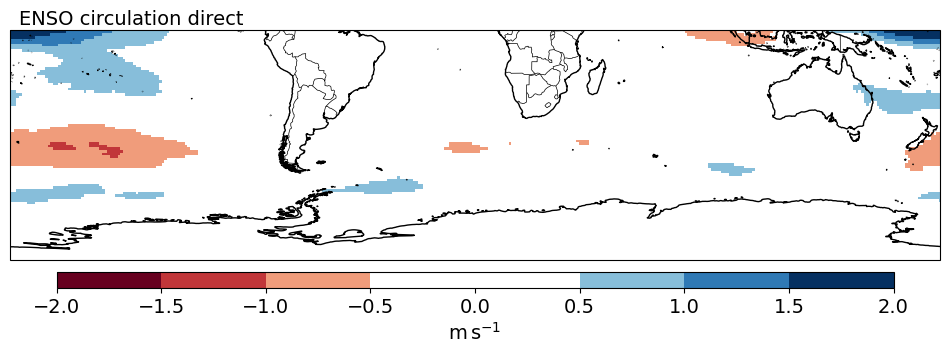

In [13]:
plot_map(1, u850_all_comp[0], 'ENSO circulation direct', '$\mathrm{m\,s^{-1}}$', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.RdBu)
plt.savefig('regression_maps_U850/ENSO_U850_direct_SON.jpg')

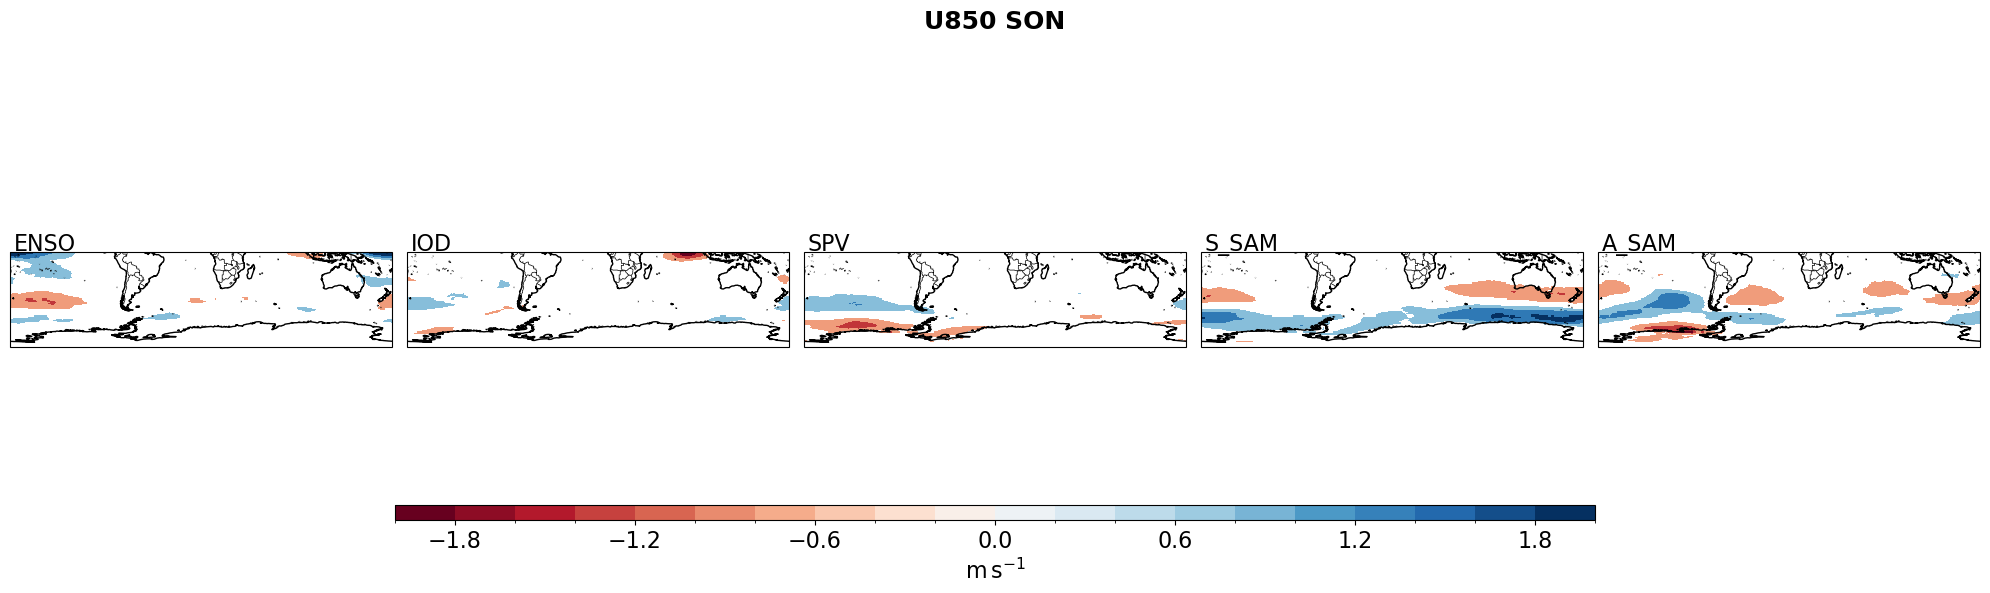

In [14]:
subplots_map(u850_all_comp, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], cmap=plt.cm.RdBu, unit='$\mathrm{m\,s^{-1}}$', heading='U850 SON')

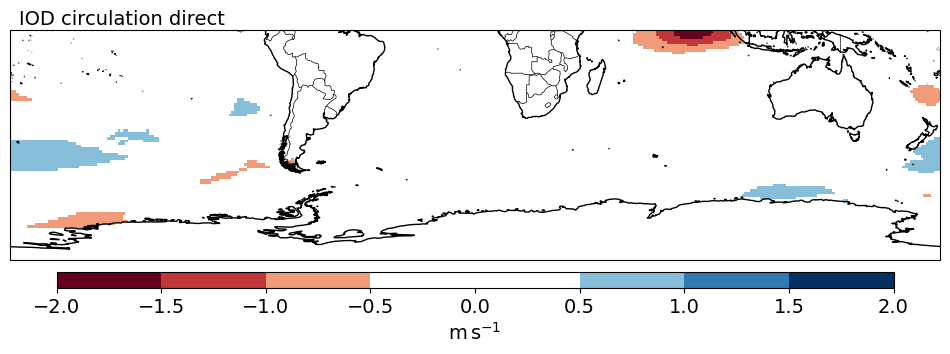

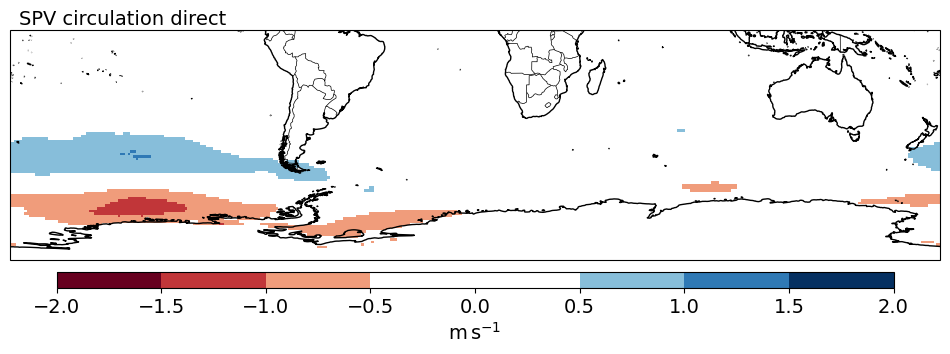

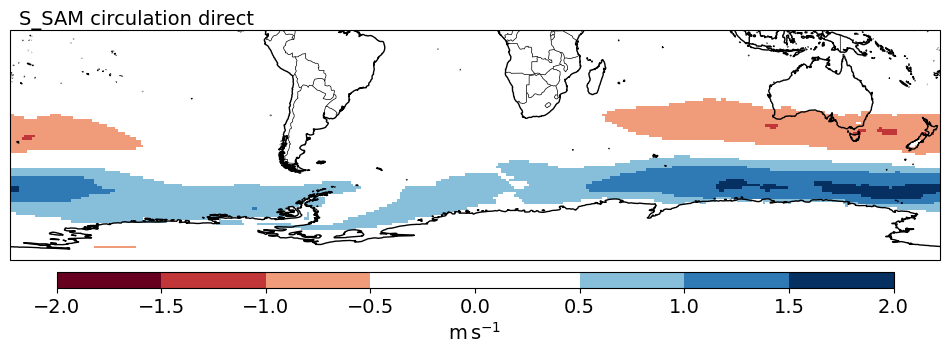

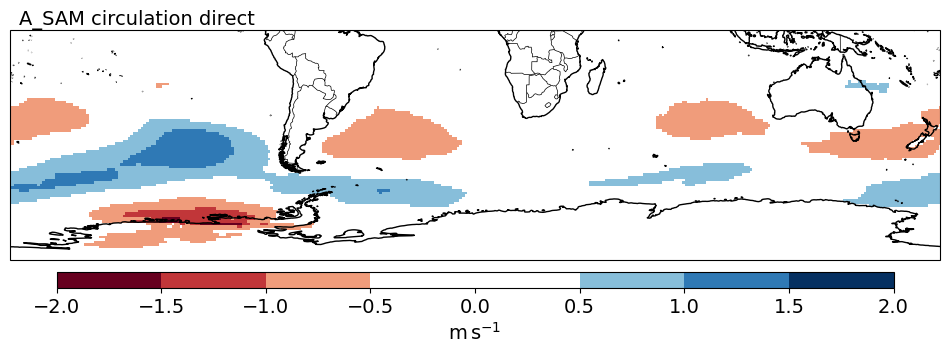

In [15]:
plot_map(1, u850_all_comp[1], 'IOD circulation direct', '$\mathrm{m\,s^{-1}}$', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.RdBu)
plt.savefig('regression_maps_U850/IOD_U850_direct_SON.jpg')

plot_map(1, u850_all_comp[2], 'SPV circulation direct', '$\mathrm{m\,s^{-1}}$', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.RdBu)
plt.savefig('regression_maps_U850/SPV_U850_direct_SON.jpg')

plot_map(1, u850_all_comp[3], 'S_SAM circulation direct', '$\mathrm{m\,s^{-1}}$', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.RdBu)
plt.savefig('regression_maps_U850/S_SAM_U850_direct_SON.jpg')

plot_map(1, u850_all_comp[len(u850_all_comp)-1], 'A_SAM circulation direct', '$\mathrm{m\,s^{-1}}$', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.RdBu)
plt.savefig('regression_maps_U850/A_SAM_U850_direct_SON.jpg')


In [16]:
u850_IOD_SON = conditioning_everything_fast(u850_chunked_SON, ['IOD'],'U')
u850_IOD_SON=[m.compute() for m in u850_IOD_SON]

IOD done


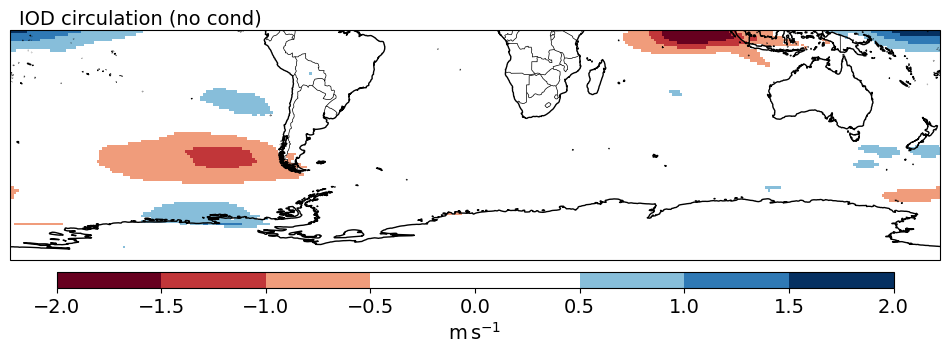

In [17]:
plot_map(1, u850_IOD_SON[0], 'IOD circulation (no cond)', '$\mathrm{m\,s^{-1}}$', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.RdBu)
plt.savefig('regression_maps_U850/IOD_U850_nocond_SON.jpg')
